In [1]:
import gdown
url="https://drive.google.com/file/d/1shVUmb6Ab56f5kwpFL0xHwlMRZAprjEi/view?usp=drive_link"
file_id=url.split("/")[-2]
file_id

'1shVUmb6Ab56f5kwpFL0xHwlMRZAprjEi'

In [3]:
import os 

In [4]:
%pwd

'/Users/aashuanand/AI-Powered-Precision-Agriculture-Monitoring-System/notebooks'

In [5]:
os.chdir("../")

In [6]:
%pwd

'/Users/aashuanand/AI-Powered-Precision-Agriculture-Monitoring-System'

In [6]:
url = f"https://drive.google.com/uc?id={file_id}"

gdown.download(url, "data/raw/Data.csv", quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1shVUmb6Ab56f5kwpFL0xHwlMRZAprjEi
To: /Users/aashuanand/AI-Powered-Precision-Agriculture-Monitoring-System/data/raw/Data.csv
100%|██████████| 407k/407k [00:00<00:00, 1.42MB/s]


'data/raw/Data.csv'

In [7]:
from pathlib import Path
import pandas as pd
INPUT_PATH = Path("data/Sentinel2_data.csv")
df= pd.read_csv(INPUT_PATH)


In [10]:
# Convert date to datetime
df['date'] = pd.to_datetime(df['date'])

# Round coordinates (3 decimal places)
df['lat_r'] = df['lat'].round(3)
df['lon_r'] = df['lon'].round(3)

# Sort values (IMPORTANT)
df = df.sort_values(by=['lat_r', 'lon_r', 'date'])

print(df.head())

     B11   B12   B2    B3    B4    B8       EVI      NDVI      NDWI      SAVI  \
13  1524   839  223   597   419  3416  1.759422  0.781486 -0.702467  1.172077   
33  2082  1424  422   799   914  2649  0.872912  0.486949 -0.536543  0.730321   
53  2363  1751  551   865  1039  2366  0.742419  0.389721 -0.464562  0.584496   
73  2297  1693  565   880  1060  2325  0.710914  0.373708 -0.450858  0.560479   
93  3023  2383  866  1237  1535  2802  0.574030  0.292137 -0.387472  0.438156   

         date        lat        lon   lat_r   lon_r  
13 2026-03-07  30.893825  74.642259  30.894  74.642  
33 2026-03-27  30.893825  74.642259  30.894  74.642  
53 2026-04-06  30.893825  74.642259  30.894  74.642  
73 2026-04-08  30.893825  74.642259  30.894  74.642  
93 2026-04-11  30.893825  74.642259  30.894  74.642  


In [11]:
df

,B11,B12,B2,B3,B4,B8,EVI,NDVI,NDWI,SAVI,date,lat,lon,lat_r,lon_r
13,1524,839,223,597,419,3416,1.759422,0.781486,-0.702467,1.172077,2026-03-07,30.893825,74.642259,30.894,74.642
33,2082,1424,422,799,914,2649,0.872912,0.486949,-0.536543,0.730321,2026-03-27,30.893825,74.642259,30.894,74.642
53,2363,1751,551,865,1039,2366,0.742419,0.389721,-0.464562,0.584496,2026-04-06,30.893825,74.642259,30.894,74.642
73,2297,1693,565,880,1060,2325,0.710914,0.373708,-0.450858,0.560479,2026-04-08,30.893825,74.642259,30.894,74.642
93,3023,2383,866,1237,1535,2802,0.574030,0.292137,-0.387472,0.438156,2026-04-11,30.893825,74.642259,30.894,74.642
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16,2399,2072,1035,1361,1606,2167,0.347025,0.148688,-0.228458,0.223003,2026-03-07,30.957842,74.625268,30.958,74.625
36,2586,2253,1273,1599,1793,2350,0.390987,0.134444,-0.190175,0.201641,2026-03-27,30.957842,74.625268,30.958,74.625
56,2611,2270,1360,1678,1864,2472,0.439688,0.140221,-0.191325,0.210308,2026-04-06,30.957842,74.625268,30.958,74.625
76,2594,2282,1387,1706,1895,2477,0.422290,0.133120,-0.184317,0.199657,2026-04-08,30.957842,74.625268,30.958,74.625


In [17]:
grouped = df.groupby(['lat', 'lon'])

print("Total locations:", len(grouped))

for (lat, lon), group in grouped:
    print(f"\nLocation: ({lat}, {lon})")
    print(group[['date', 'NDVI', 'EVI', 'NDWI', 'SAVI']])
    print(len(group))
    

Total locations: 20

Location: (30.89382519632875, 74.64225911121832)
         date      NDVI       EVI      NDWI      SAVI
13 2026-03-07  0.781486  1.759422 -0.702467  1.172077
33 2026-03-27  0.486949  0.872912 -0.536543  0.730321
53 2026-04-06  0.389721  0.742419 -0.464562  0.584496
73 2026-04-08  0.373708  0.710914 -0.450858  0.560479
93 2026-04-11  0.292137  0.574030 -0.387472  0.438156
5

Location: (30.90455291417864, 74.60768666171342)
         date      NDVI       EVI      NDWI      SAVI
3  2026-03-07  0.518473  1.046316 -0.531589  0.777615
23 2026-03-27  0.454237  0.947283 -0.480039  0.681273
43 2026-04-06  0.446980  1.061975 -0.458728  0.670395
63 2026-04-08  0.465959  1.124867 -0.471815  0.698862
83 2026-04-11  0.435534  1.088042 -0.445773  0.653233
5

Location: (30.90902906139593, 74.5961570298781)
         date      NDVI       EVI      NDWI      SAVI
0  2026-03-07  0.708300  1.479942 -0.648414  1.062309
20 2026-03-27  0.663314  1.460713 -0.620005  0.994839
40 2026-04-06  0.

In [12]:
import numpy as np

# Final labeling logic
def final_label(row):
    # Rule 1: Absolute NDVI threshold
    if row['NDVI'] < 0.3:
        return 0

    # Rule 2 + 3: Significant drop + persistence
    if row['ndvi_drop'] >= 0.25:
        if row['next_ndvi'] < row['prev_ndvi'] * 0.75:
            return 0

    return 1

def smooth_labels(group):
    labels = group['label'].values

    for i in range(1, len(labels)-1):
        if labels[i-1] == 1 and labels[i] == 0 and labels[i+1] == 1:
            labels[i] = 1

    group['label'] = labels
    return group

def process_group(group):
    group = group.sort_values('date').copy()

    # Lag and lead features
    group['prev_ndvi'] = group['NDVI'].shift(1)
    group['next_ndvi'] = group['NDVI'].shift(-1)

    # NDVI drop (robust to division by zero)
    group['ndvi_drop'] = (group['prev_ndvi'] - group['NDVI']) / (group['prev_ndvi'] + 1e-6)


    group['label'] = group.apply(final_label, axis=1)

    return group


# Apply once (clean pipeline)
df_labeled = df.groupby(['lat_r', 'lon_r']).apply(process_group).reset_index(drop=True)

df_labeled = df_labeled.dropna(subset=['prev_ndvi', 'next_ndvi'])
df_labeled = df_labeled.groupby(['lat_r', 'lon_r']).apply(smooth_labels).reset_index(drop=True)

/var/folders/rx/7t4zqkc53ls86qns7rr62hnc0000gn/T/ipykernel_66920/1051558647.py:43: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_labeled = df.groupby(['lat_r', 'lon_r']).apply(process_group).reset_index(drop=True)
/var/folders/rx/7t4zqkc53ls86qns7rr62hnc0000gn/T/ipykernel_66920/1051558647.py:46: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_labeled = df_labeled.groupby(['lat_r', 'lon_r']).apply(smooth_labels).r

In [13]:
df_labeled['label'].value_counts()

label
1    1283
0     313
Name: count, dtype: int64

# justify

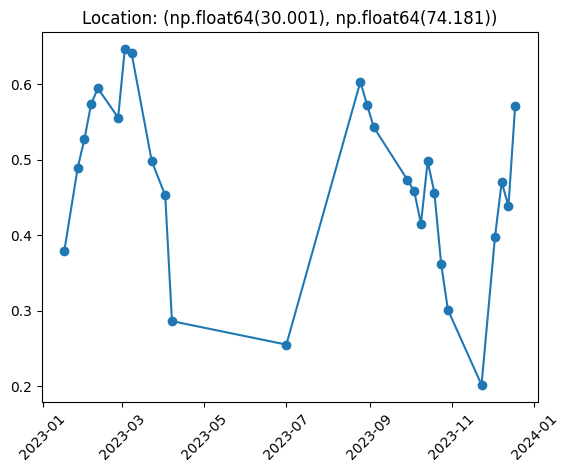

In [40]:
import matplotlib.pyplot as plt

# pick one location
for key, group in df_labeled.groupby(['lat_r','lon_r']):
    group = group.sort_values('date')

    plt.plot(group['date'], group['NDVI'], marker='o')
    plt.title(f"Location: {key}")
    plt.xticks(rotation=45)
    plt.show()

    break

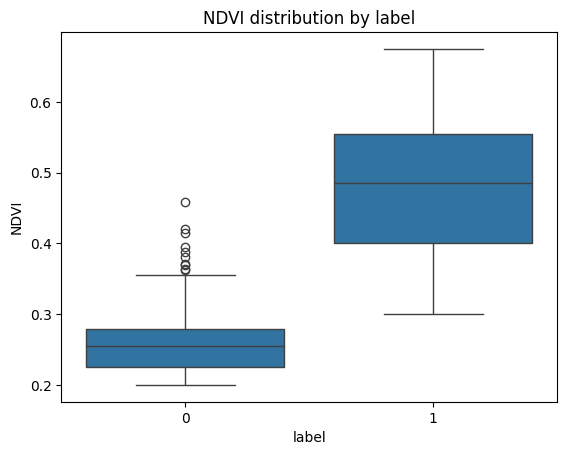

In [35]:
import seaborn as sns

sns.boxplot(x='label', y='NDVI', data=df_labeled)
plt.title("NDVI distribution by label")
plt.show()

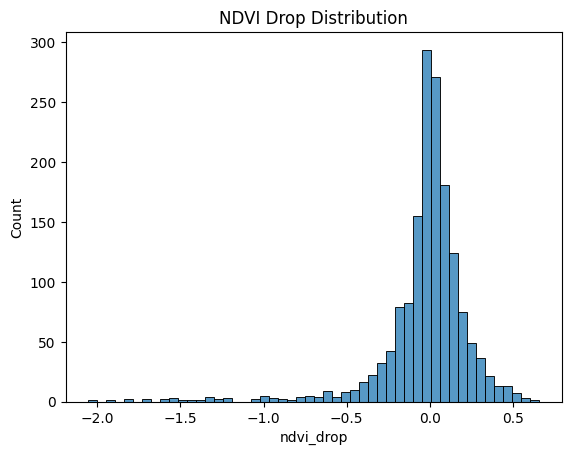

In [36]:
sns.histplot(df_labeled['ndvi_drop'], bins=50)
plt.title("NDVI Drop Distribution")
plt.show()

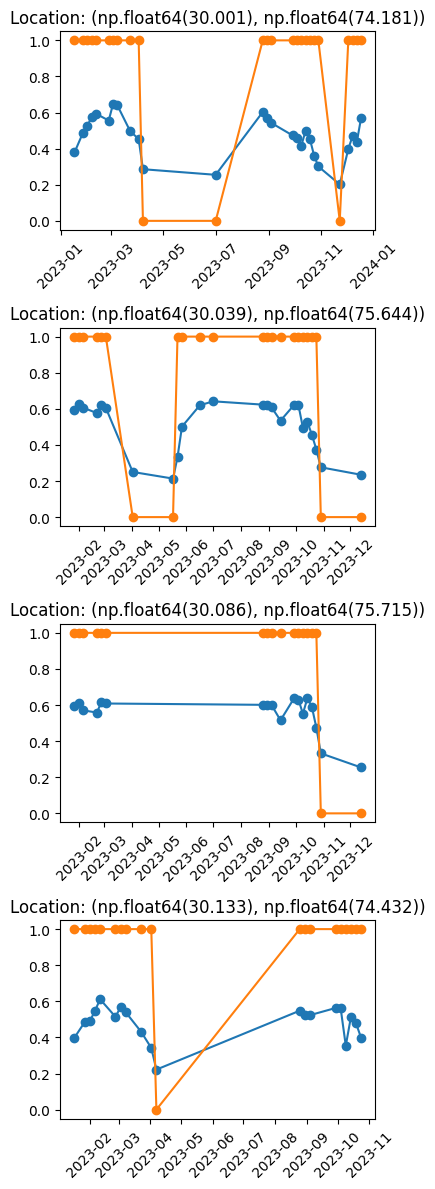

In [37]:
import matplotlib.pyplot as plt
grp=df_labeled.groupby(['lat_r','lon_r'])
fig, ax = plt.subplots(4, 1, figsize=(4, 12))

for i, (key, group) in enumerate(grp):
    if i >= 4:
        break

    ax[i].plot(group['date'], group['NDVI'], marker='o')
    ax[i].plot(group['date'],group['label'],marker='o')
    ax[i].set_title(f"Location: {key}")
    ax[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# next phase -- after label

In [42]:
df_labeled.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1596 entries, 0 to 1595
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   B11        1596 non-null   int64         
 1   B12        1596 non-null   int64         
 2   B2         1596 non-null   int64         
 3   B3         1596 non-null   int64         
 4   B4         1596 non-null   int64         
 5   B8         1596 non-null   int64         
 6   NDVI       1596 non-null   float64       
 7   NDWI       1596 non-null   float64       
 8   date       1596 non-null   datetime64[ns]
 9   lat        1596 non-null   float64       
 10  lon        1596 non-null   float64       
 11  lat_r      1596 non-null   float64       
 12  lon_r      1596 non-null   float64       
 13  prev_ndvi  1596 non-null   float64       
 14  next_ndvi  1596 non-null   float64       
 15  ndvi_drop  1596 non-null   float64       
 16  label      1596 non-null   int64         


In [49]:
df_labeled['ndvi_mean_3'] = df_labeled.groupby(['lat_r','lon_r'])['NDVI'].rolling(3).mean().reset_index(level=[0,1], drop=True)
df_labeled['month'] = df_labeled['date'].dt.month
df_labeled['ndvi_diff'] = df_labeled['NDVI'] - df_labeled['prev_ndvi']
df_model = df_labeled.dropna()

In [50]:
features = [
    'B2','B3','B4','B8','B11','B12',
    'prev_ndvi','ndvi_diff','ndvi_mean_3','month'
]

X = df_labeled[features]
y = df_labeled['label']

In [53]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestClassifier(n_estimators=100)
model.fit(X_train, y_train)

RandomForestClassifier()

In [54]:
y_pred=model.predict(X_test)

In [55]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.940625
              precision    recall  f1-score   support

           0       0.85      0.88      0.86        68
           1       0.97      0.96      0.96       252

    accuracy                           0.94       320
   macro avg       0.91      0.92      0.91       320
weighted avg       0.94      0.94      0.94       320



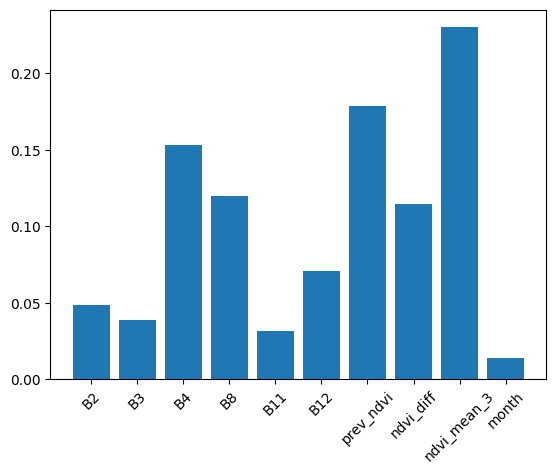

In [56]:
import matplotlib.pyplot as plt

importances = model.feature_importances_

plt.bar(features, importances)
plt.xticks(rotation=45)
plt.show()

In [10]:
def outer():
    def inner():
        print("Hello")
    return inner

f = outer()
f()

Hello


In [12]:
def decorator(func):
    def wrapper():
        print("Before")
        func()
        print("After")
    return wrapper
@decorator
def greet():
    print("Hello")

In [13]:
greet()

Before
Hello
After
